# Function 4 — 4D Warehouse Placement

**Objective:** maximise Y, the negative cost difference from baseline
**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI), ξ = 0.10 — strong exploration,
because the problem description warns of many local optima
**Y transform:** `log(-Y)` compresses a 12× range to roughly [1.3, 3.9]

---

Four placement parameters in [0, 1], returning a negative cost. One query per
week, five rounds completed.

## Problem characteristics

| Property | Value | Implication |
|---|---|---|
| Dimensions | 4D | Moderate — a standard GP is still tractable and remains the right tool |
| Dataset | 30 supplied, 35 total | Reasonable for a GP, though still under-sampled in four dimensions |
| Y range | −48 to −3.8 | Large spread, roughly 12× — needs a transform |
| Objective | Maximise (negative cost) | Find the least-cost warehouse placement |
| Surface | Dynamic, many local optima | Argues for strong exploration |
| Noise | ML approximation error | Heteroscedastic — varies by region |

The approach is GP-BO with Matérn 5/2 and EI, with three deliberate
additions: a log transform, a raised ξ, and a large initial noise level. Each
is explained in the section where it is applied, and section 7 examines how
well each held up.

With four inputs the surface cannot be drawn directly, so the visualisation
shows all C(4,2) = 6 pairwise slices, fixing the other two axes at the next
sample's values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_4.csv` rather than pasted inline.

Two problems in the original hard-coded version make the case for this:

**A shape mismatch.** `X` had grown to 35 rows while `Y_raw` had 34 values — a
pending round-6 query had been added before its result came back.
`model.fit(X, Y)` fails in that state.

**A missing observation.** Round 4's result, `[0.0, 0.493173, 1.0, 1.0] →
−35.8817`, was never added to the arrays. The `Y_raw` list runs straight from
round 3's −35.979 to round 5's −37.260. The model was therefore fitted on four
rounds while appearing to use five, and nothing in the code would reveal it.

Both failures come from maintaining the same numbers in two places. A single
CSV with a `week` column makes them impossible.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_4.csv", float_precision="round_trip")

X     = df[["x1", "x2", "x3", "x4"]].values   # placement parameters
Y_raw = df["y"].values                        # negative cost
week  = df["week"].values                     # 0 = supplied, 1-5 = ours

print("Data shapes:")
print(f"  X     : {X.shape}")
print(f"  Y_raw : {Y_raw.shape}")
print(f"\nY_raw range : [{Y_raw.min():.4f},  {Y_raw.max():.4f}]")

# Confirm every round is present - this is what the original script lost.
print(f"\nRounds present: {sorted(set(week))}")

df.tail(6)

Data shapes:
  X     : (35, 4)
  Y_raw : (35,)

Y_raw range : [-47.9808,  -3.7894]

Rounds present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,week,x1,x2,x3,x4,y
29,0,0.854811,0.493965,0.735310,0.808092,-23.139428
30,1,0.577700,0.428700,0.432500,0.274500,-3.789395
31,2,0.999999,0.002103,0.999999,0.999999,-47.980838
32,3,0.537487,0.999999,0.999999,0.000000,-35.978814
33,4,0.000000,0.493173,1.000000,1.000000,-35.881733
34,5,1.000000,0.000000,1.000000,0.631579,-37.259732


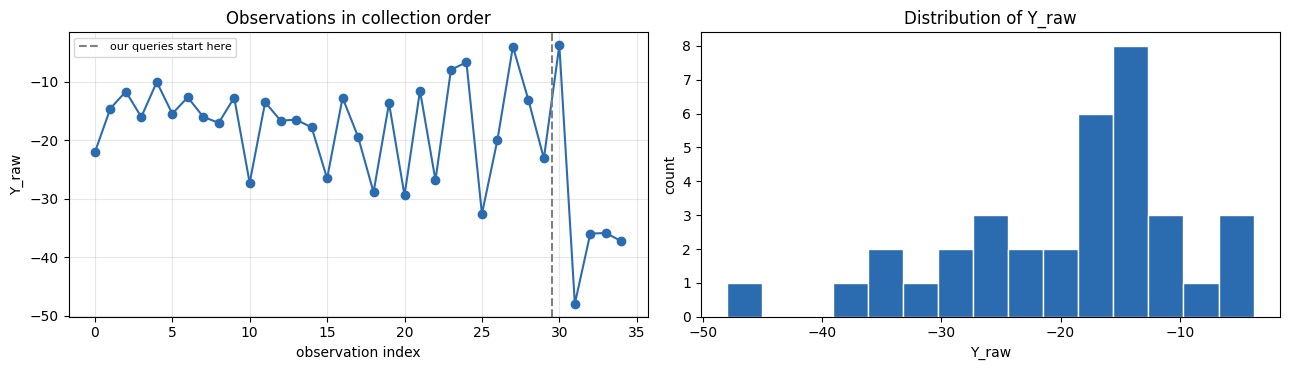

In [3]:
# Left  : scores in collection order, our five queries right of the line
# Right : how the scores are distributed
#
# The spread on the right is what motivates the transform in section 2.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y_raw, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y_raw")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y_raw, bins=15, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y_raw")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y_raw")

plt.tight_layout()
plt.show()

## 2. Y transform — log(−Y)

**Addition 1 of 3.**

`Y_raw` spans −48 to −3.8, a 12× range.

### Why that breaks the fit

A GP fits one smooth surface through every observation simultaneously, using a
single length-scale to describe how fast the surface varies.

On the raw scale those observations impose contradictory demands. Capturing the
structure near −4 — where the incumbent sits, and where the search needs to be
sharp — requires an extremely short length-scale. Handling the −48 region
requires a long one. The kernel optimiser cannot satisfy both, so the fit ends
up poor in at least one region, and in practice it is the region near the
incumbent that suffers: the model chases the large-magnitude values and ignores
the fine structure where it matters.

Spread the same values evenly on a log scale and the conflict disappears. One
length-scale can then work well everywhere.

### The mapping

`log(-Y)` gives:

| Raw | Transformed | |
|---|---|---|
| −47.98 | 3.87 | worst placement |
| −3.79 | 1.33 | best placement so far |

The compressed range [1.33, 3.87] is one the GP can fit uniformly. All `Y_raw`
are negative, so `-Y_raw` is positive throughout and no offset is needed.

The transform is monotonic, so maximising `log(-Y)` is equivalent to maximising
`-Y`, which is equivalent to minimising cost.

### Interaction with normalize_y

`normalize_y=True` in the GP subtracts the mean and divides by the standard
deviation of the target before fitting. That works far better when the target
is already on a compact, roughly uniform scale — centring and scaling a
distribution that spans 12× does not fix the underlying problem, it just moves
it. The transform and `normalize_y` work together rather than duplicating each
other.

The acquisition function and next-sample selection operate on the transformed
scale; the summary reports raw values.

In [4]:
# -----------------------------------------------------------------
#  Y TRANSFORM  —  log(-Y)
# -----------------------------------------------------------------
Y = np.log(-Y_raw)        # all Y_raw are negative, so -Y_raw > 0

print(f"Y_raw range         : [{Y_raw.min():.4f},  {Y_raw.max():.4f}]")
print(f"Y_transformed range : [{Y.min():.4f},  {Y.max():.4f}]")

print("\nEffect on the extremes:")
worst, best = np.argmin(Y_raw), np.argmax(Y_raw)
print(f"  worst: {Y_raw[worst]:8.2f}  ->  {Y[worst]:.3f}")
print(f"  best : {Y_raw[best]:8.2f}  ->  {Y[best]:.3f}")

Y_raw range         : [-47.9808,  -3.7894]
Y_transformed range : [1.3322,  3.8708]

Effect on the extremes:
  worst:   -47.98  ->  3.871
  best :    -3.79  ->  1.332


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | Smooth but flexible — suitable for a warehouse cost surface with sharp transitions. |
| `length_scale` | 0.3, bounds (0.01, 2.0) | A **single shared** length-scale across all four dimensions. |
| `WhiteKernel` | 1.0, bounds (1e-3, 10.0) | **Addition 3 of 3** — see below. |

### Why the noise level starts high

**Addition 3 of 3.** This is the largest initial noise term used anywhere in
the project — Function 3 uses 0.01, Function 5 uses 0.05.

The reason is where these outputs come from. They are not direct measurements
but an **ML approximation** of a costly biweekly calculation. That approximator
introduces systematic error, and the size of that error varies across the input
space: it is heteroscedastic, not uniform.

A GP's `WhiteKernel` can only model a single constant noise level, so it cannot
represent heteroscedasticity directly. Starting it at 1.0 with generous bounds
(1e-3, 10.0) is a pragmatic compromise: rather than assert a value, let the
kernel optimiser learn what the data supports. The fitted value is printed
below, and section 7 examines what it turned out to be.

### A note on ARD

An earlier version of the header described this kernel as using ARD — automatic
relevance determination, one length-scale per dimension, letting the model
learn which parameters matter most. It does not. The kernel uses a single
scalar `length_scale=0.3` shared across all four inputs.

ARD would be a reasonable thing to try here, and is listed in section 7 as a
possible improvement. But the model as run assumes all four dimensions vary at
the same rate, and the write-up should say so.

In [5]:
# -----------------------------------------------------------------
#  KERNEL  —  single shared length-scale (not ARD)
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # overall signal amplitude
    )
    * Matern(
        nu=2.5,                                 # smooth, allows sharp ridges
        length_scale=0.3,                       # one scale for all 4 dims
        length_scale_bounds=(0.01, 2.0),
    )
    + WhiteKernel(
        noise_level=1.0,                        # ML approximation error
        noise_level_bounds=(1e-3, 10.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
# -----------------------------------------------------------------
xi = 0.10      # strong exploration - the surface has many local optima

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y)

print(f"Optimised kernel:\n  {model.kernel_}")

fitted_ls    = model.kernel_.k1.k2.length_scale
fitted_noise = model.kernel_.k2.noise_level
print(f"\n  fitted length_scale : {fitted_ls:.4g}   (started at 0.3)")
print(f"  fitted noise_level  : {fitted_noise:.4g}   (started at 1.0)")

if fitted_noise <= 1e-3 * 1.01:
    print("\n  NOTE: the noise level has been driven to its LOWER BOUND.")
    print("  We started it at 1.0 assuming substantial approximation error,")
    print("  and the optimiser pushed it as low as the bounds permit - the")
    print("  data looks far cleaner than the heteroscedastic assumption")
    print("  predicted. See section 7.")

Optimised kernel:
  1.08**2 * Matern(length_scale=0.58, nu=2.5) + WhiteKernel(noise_level=0.001)

  fitted length_scale : 0.5797   (started at 0.3)
  fitted noise_level  : 0.001   (started at 1.0)

  NOTE: the noise level has been driven to its LOWER BOUND.
  We started it at 1.0 assuming substantial approximation error,
  and the optimiser pushed it as low as the bounds permit - the
  data looks far cleaner than the heteroscedastic assumption
  predicted. See section 7.


## 4. Does the model actually work?

Leave-one-out cross-validation: hide one observation, refit on the rest,
predict the hidden point, repeat for all 35.

R² of 1.0 is perfect, 0.0 is no better than always predicting the average, and
below 0.0 is worse than that.

This matters more here than elsewhere, because Function 4 has the largest
dataset of the four-dimensional problems and the strongest exploration setting.
If the model is good and the search still stalled, the problem lies in the
acquisition step rather than the surrogate.

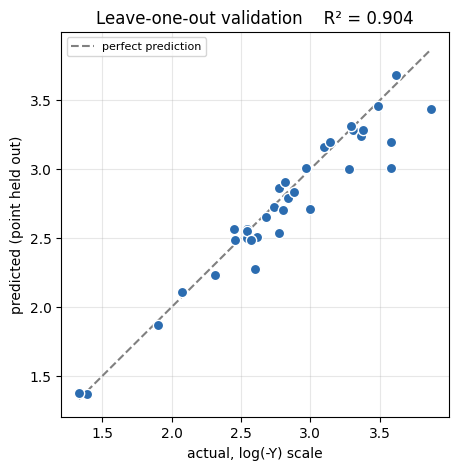

R² = 0.904

Strong. The model predicts held-out points well, so if the search
still stalled the cause lies in the acquisition step, not here.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.01, 2.0))
         + WhiteKernel(1.0, (1e-3, 10.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y - Y.mean()) ** 2).sum()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y, predicted, s=55, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y.min(), predicted.min()), max(Y.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual, log(-Y) scale")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out validation    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"R² = {r2:.3f}")
if r2 >= 0.7:
    print("\nStrong. The model predicts held-out points well, so if the search")
    print("still stalled the cause lies in the acquisition step, not here.")
elif r2 >= 0.4:
    print("\nModerate. The model has learned real structure.")
else:
    print("\nWeak. Treat the model's suggestions with caution.")

## 5. Prediction grid and Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z)

**Addition 2 of 3: ξ = 0.10** — the strongest exploration setting used on any
function in this project. Two reasons were behind it:

1. **The problem description explicitly warns about local optima.** A search
   that settles too quickly on a multimodal surface polishes the wrong peak.
2. **35 points in four dimensions is under-sampled.** The unit hypercube has a
   lot of room, and a few dozen points leave most of it unvisited. That argues
   for covering ground before committing.

Both arguments are sound in the abstract. Section 7 examines whether the
setting produced the behaviour they imply.

The grid is 20⁴ = 160,000 candidate points.

In [7]:
# -----------------------------------------------------------------
#  4D PREDICTION GRID  (20^4 = 160,000 candidates)
# -----------------------------------------------------------------
n_grid = 20
x_vals = np.linspace(0, 1, n_grid)
g      = np.meshgrid(x_vals, x_vals, x_vals, x_vals, indexing="ij")
X_grid = np.column_stack([gi.ravel() for gi in g])

print(f"Grid size : {len(X_grid):,} points")

post_mean, post_std = model.predict(X_grid, return_std=True)


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT  (on the transformed scale)
# -----------------------------------------------------------------
Y_best = Y.max()


def expected_improvement(mu, sigma, y_best, xi=0.10):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. Set it to 0.0
    # and zero the resulting EI: a point with no uncertainty offers no
    # possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
best_idx = np.argmax(ei_values)
x_next   = X_grid[best_idx]

best_raw_idx = np.argmax(Y_raw)
print(f"\nCurrent best Y_raw    : {Y_raw[best_raw_idx]:.6f}")
print(f"  (log scale)         : {Y[best_raw_idx]:.6f}")
print(f"  at X                : {X[best_raw_idx]}")
print(f"  found in round      : {week[best_raw_idx]}")
print(f"\nNext point to sample  : {np.round(x_next, 6).tolist()}")
print(f"Max EI value          : {ei_values[best_idx]:.6f}")

on_bound = int(np.sum((x_next <= 1e-6) | (x_next >= 0.999)))
print(f"Coordinates on the boundary: {on_bound} of 4")

Grid size : 160,000 points



Current best Y_raw    : -3.789395
  (log scale)         : 1.332206
  at X                : [0.5777 0.4287 0.4325 0.2745]
  found in round      : 1

Next point to sample  : [1.0, 1.0, 0.842105, 0.0]
Max EI value          : 0.035302
Coordinates on the boundary: 3 of 4


## 6. Visualisation

Eighteen panels: six pairwise slices across three rows (GP mean, uncertainty,
EI). In each panel the other two parameters are held at the next sample's
values, shown in the panel title.

The middle row is the most diagnostic. EI can only choose sensibly if
uncertainty is low near the observations and high away from them.

A caveat on reading these: the white dots are **all** observations projected
onto the plane, including ones whose fixed coordinates are far from the slice.
A point can look adjacent to the star while being distant in the other two
dimensions — and in four dimensions that happens often.

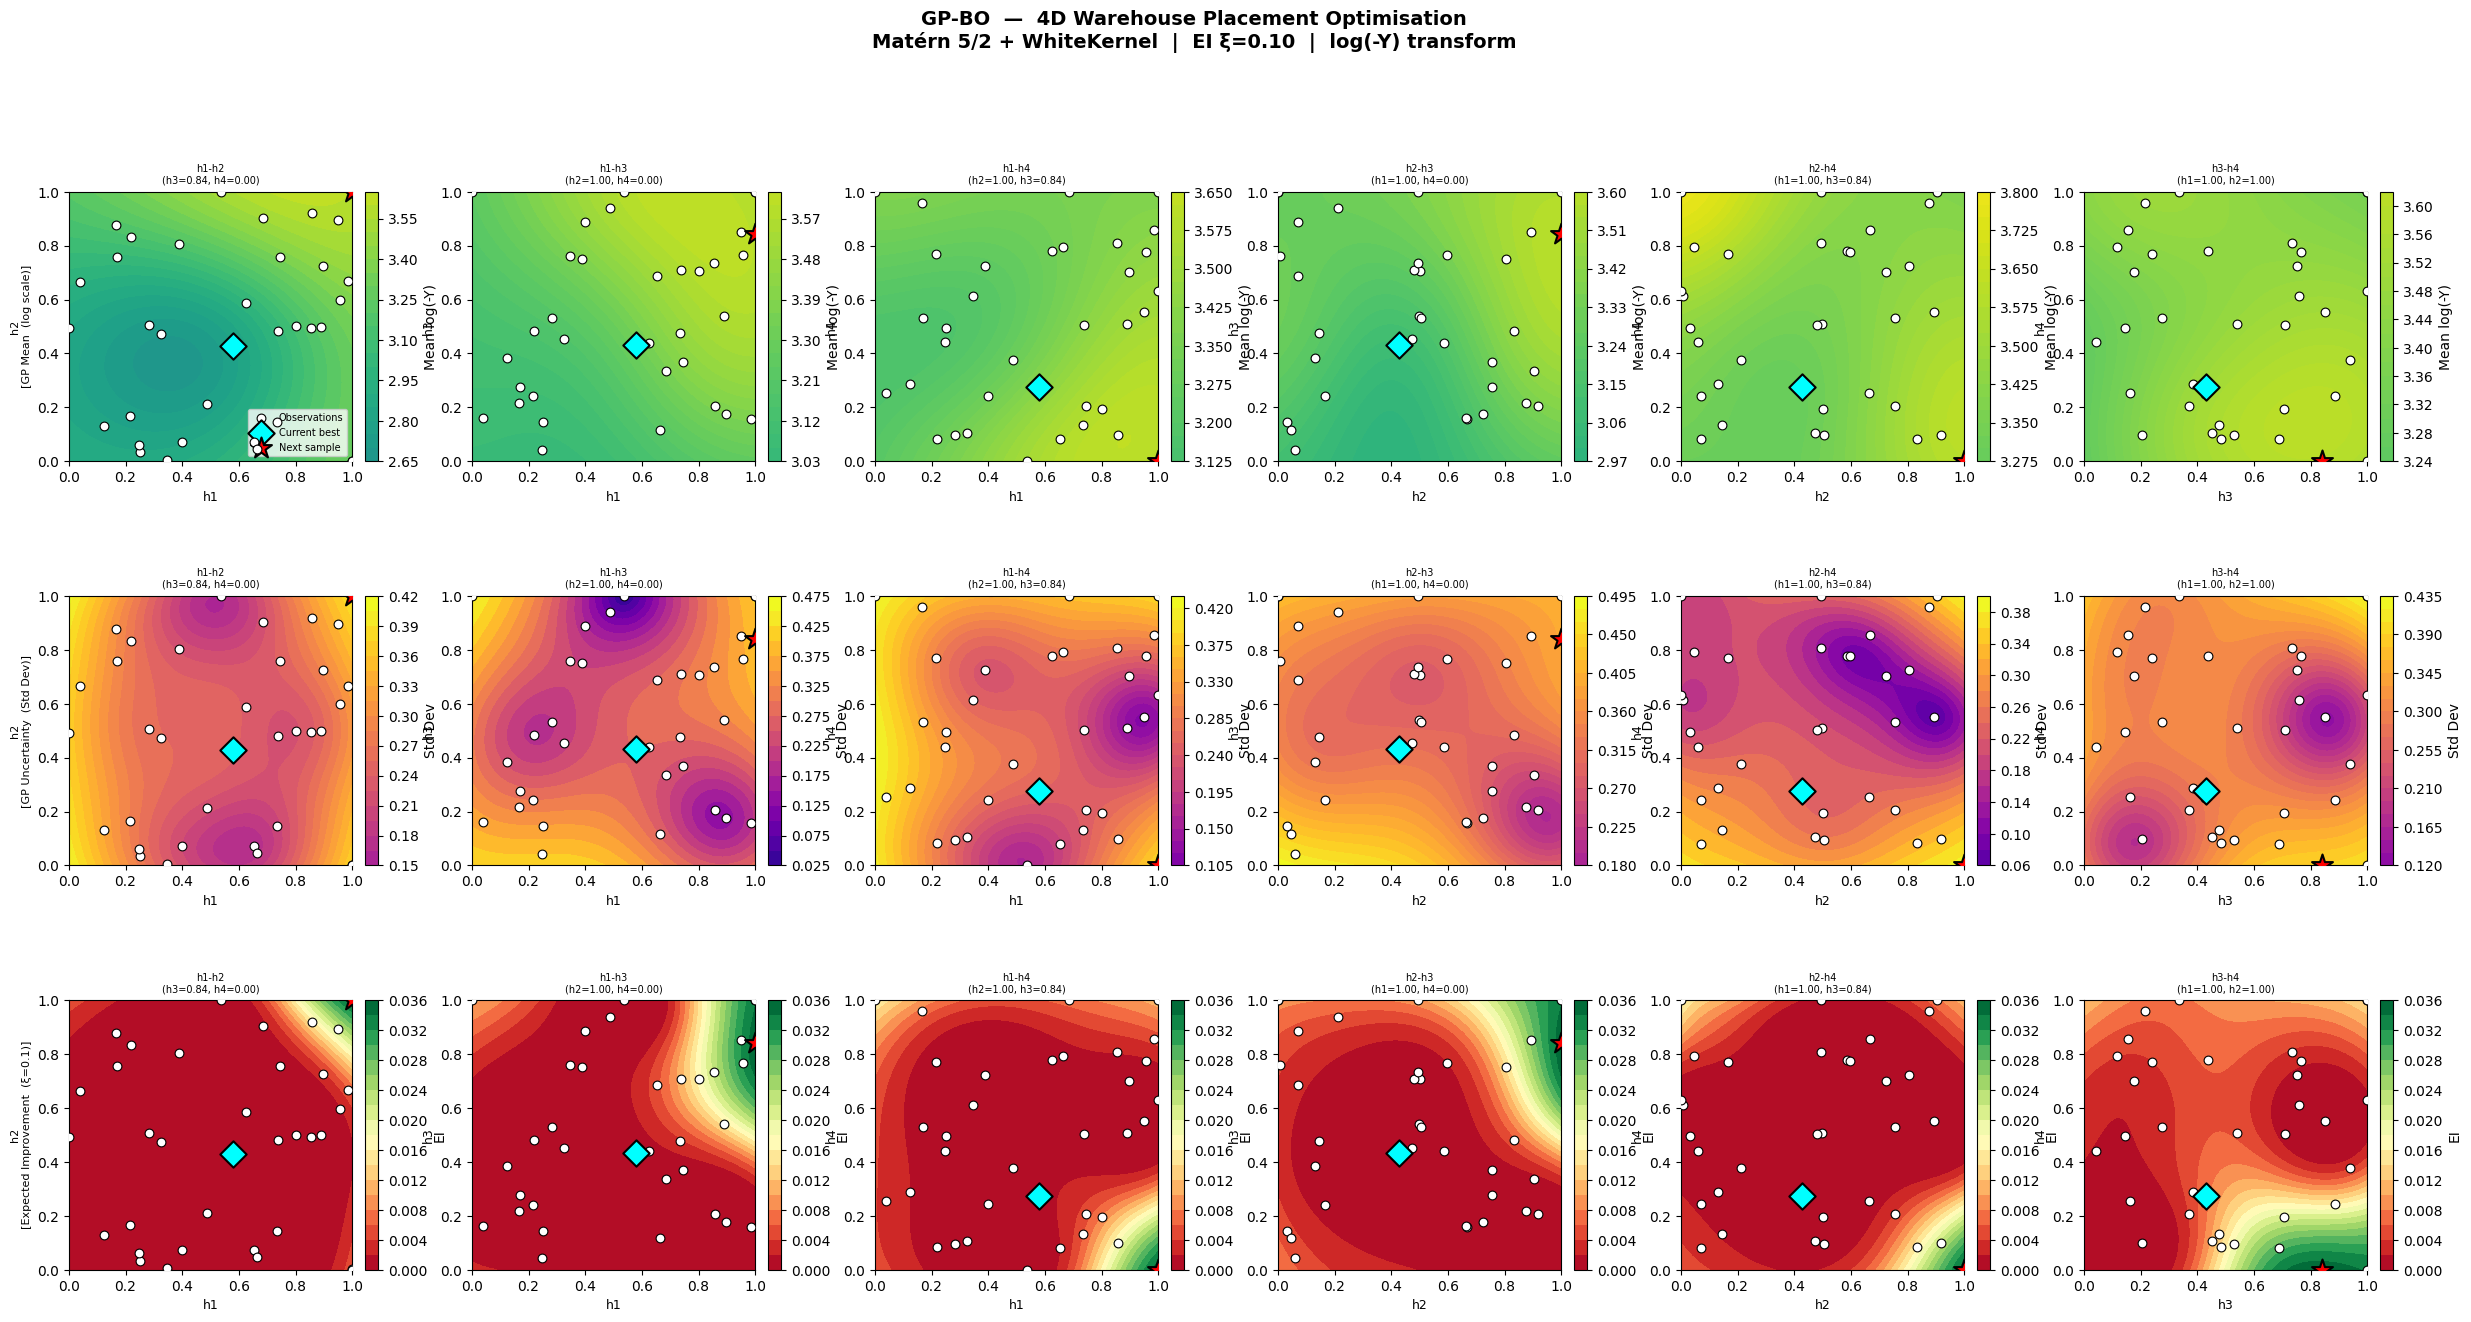

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION — C(4,2) = 6 pairwise slices, 3 rows
# -----------------------------------------------------------------
n_slice    = 80
s_vals     = np.linspace(0, 1, n_slice)
S1, S2     = np.meshgrid(s_vals, s_vals)
axis_names = ["h1", "h2", "h3", "h4"]
PAIRS      = list(combinations(range(4), 2))       # 6 pairs

ROW_LABELS = [
    "GP Mean  (log scale)",
    "GP Uncertainty  (Std Dev)",
    f"Expected Improvement  (\u03be={xi})",
]

fig = plt.figure(figsize=(30, 14))
fig.suptitle(
    "GP-BO  —  4D Warehouse Placement Optimisation\n"
    "Mat\u00e9rn 5/2 + WhiteKernel  |  EI \u03be=0.10  |  log(-Y) transform",
    fontsize=14, fontweight="bold", y=1.01,
)
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.50, wspace=0.30)

best_raw_obs = np.argmax(Y_raw)

for row in range(3):
    for col, (ax_a, ax_b) in enumerate(PAIRS):

        ax = fig.add_subplot(gs[row, col])

        fixed_axes = [i for i in range(4) if i not in (ax_a, ax_b)]
        title_fix  = ", ".join(
            f"{axis_names[i]}={x_next[i]:.2f}" for i in fixed_axes
        )

        # 2-D slice: vary two parameters, fix the other two at x_next
        grid          = np.tile(x_next, (n_slice ** 2, 1))
        grid[:, ax_a] = S1.ravel()
        grid[:, ax_b] = S2.ravel()

        mu_sl, std_sl = model.predict(grid, return_std=True)
        ei_sl = expected_improvement(mu_sl, std_sl, Y_best, xi)

        if row == 0:
            Z, cmap    = mu_sl.reshape(n_slice, n_slice), "viridis"
            vmin, vmax = Y.min(), Y.max()
            cb_label   = "Mean log(-Y)"
        elif row == 1:
            Z, cmap    = std_sl.reshape(n_slice, n_slice), "plasma"
            vmin, vmax = 0, std_sl.max()
            cb_label   = "Std Dev"
        else:
            Z, cmap    = ei_sl.reshape(n_slice, n_slice), "RdYlGn"
            vmin, vmax = 0, max(ei_sl.max(), 1e-9)
            cb_label   = "EI"

        cf = ax.contourf(S1, S2, Z, levels=20, cmap=cmap, vmin=vmin, vmax=vmax)

        ax.scatter(X[:, ax_a], X[:, ax_b], c="white", s=40,
                   edgecolors="black", linewidths=0.8, zorder=10,
                   label="Observations")
        ax.scatter(X[best_raw_obs, ax_a], X[best_raw_obs, ax_b],
                   c="cyan", s=180, marker="D", edgecolors="black",
                   linewidths=1.5, zorder=11, label="Current best")
        ax.scatter(x_next[ax_a], x_next[ax_b], c="red", s=250,
                   marker="*", edgecolors="black", linewidths=1.5,
                   zorder=12, label="Next sample")

        ax.set_xlabel(axis_names[ax_a], fontsize=9)
        ax.set_title(f"{axis_names[ax_a]}-{axis_names[ax_b]}\n({title_fix})",
                     fontsize=7)

        if col == 0:
            ax.set_ylabel(f"{axis_names[ax_b]}\n[{ROW_LABELS[row]}]", fontsize=8)
        else:
            ax.set_ylabel(axis_names[ax_b], fontsize=9)

        plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label=cb_label)

        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc="lower right")

plt.show()

## 7. Round-by-round review

Round 1 improved the best value by 5.9%, from −4.026 to −3.789. Rounds 2 to 5
then returned −47.98, −35.98, −35.88 and −37.26 — an order of magnitude worse
than the incumbent.

**This is the informative failure of the project, because the model is fine.**

The R² above is the highest of all eight functions. This surrogate predicts
held-out points well. It is not a case of the search being guided by a model
that knows nothing — the problem lies in what was done with a model that knew
quite a lot.

**Where the setting went wrong.** ξ = 0.10 was chosen because the problem
description warns of many local optima. That is sound reasoning from the
information available: with a multimodal surface, a search that settles too
early polishes the wrong peak.

But look at what the four exploratory rounds actually sampled:

| Round | Query | Coordinates at 0 or 1 | Result |
|---|---|---|---|
| 1 | [0.578, 0.429, 0.433, 0.275] | 0 | **−3.79** |
| 2 | [1.000, 0.002, 1.000, 1.000] | 3 | −47.98 |
| 3 | [0.537, 1.000, 1.000, 0.000] | 3 | −35.98 |
| 4 | [0.000, 0.493, 1.000, 1.000] | 3 | −35.88 |
| 5 | [1.000, 0.000, 1.000, 0.632] | 3 | −37.26 |

The one interior query improved on the incumbent. All four boundary queries
were disasters.

High ξ raises the weight on uncertainty, and on a uniform 20⁴ grid the points
with the highest uncertainty are always at the edges — they are furthest from
every observation by construction. So ξ = 0.10 did not produce *exploration* in
any useful sense; it produced four rounds of sampling the corners of a
160,000-point grid.

**A good model plus an over-aggressive setting still wastes rounds.** That is
a different lesson from Functions 1 and 3, where the model itself was the
problem.

### How the three additions held up

| Addition | Verdict |
|---|---|
| **1. `log(-Y)` transform** | **Worked.** R² of 0.90 on a 12× range is strong evidence the compressed scale let one length-scale serve the whole surface. |
| **2. ξ = 0.10** | **Backfired.** The reasoning was sound but the mechanism was not: on a uniform grid, raising the weight on uncertainty sends the search to the corners, not to unexplored interior regions. |
| **3. Noise level 1.0** | **Not supported by the data.** The optimiser drove it to its lower bound of 0.001 — three orders of magnitude below the starting value. The heteroscedastic approximation error assumed to be substantial turned out to be almost undetectable at this sample size. |

The third is worth dwelling on. The assumption was reasonable: outputs from an
ML approximator should carry systematic, region-varying error. But the fitted
value says the surface is far more predictable than that, and the R² of 0.90
agrees. Starting the noise high and letting the kernel learn it was the right
method — it is precisely what allowed the data to overturn the assumption.

**What would help:**

1. **Lower ξ to around 0.05.** The multimodality warning justified more
   exploration than default, not the maximum used.
2. **Generate candidates from a Sobol sequence rather than a grid.** A grid
   places its highest-uncertainty points at the boundary by construction, so a
   high ξ and a grid compound each other.
3. **Try ARD** — one length-scale per dimension, as the header mistakenly
   claimed was already in use. With 35 observations in four dimensions there is
   enough data to fit it, and it would reveal which of the four placement
   parameters actually matter.
4. **Tighten the noise bounds.** Now that the data has shown the noise to be
   near zero, starting at 1.0 each run wastes optimiser effort and risks a poor
   local fit.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    n_bound = int(np.sum((X[i] <= 1e-6) | (X[i] >= 0.999)))
    rows.append({
        "round":       r,
        "submitted":   "[" + ", ".join(f"{v:.3f}" for v in X[i]) + "]",
        "Y_raw":       round(float(Y_raw[i]), 4),
        "best after":  round(float(Y_raw[week <= r].max()), 4),
        "improved":    "yes" if Y_raw[i] > Y_raw[week < r].max() else "no",
        "on boundary": f"{n_bound} of 4" if n_bound else "no",
    })

pd.DataFrame(rows)

,round,submitted,Y_raw,best after,improved,on boundary
0,1,"[0.578, 0.429, 0.432, 0.275]",-3.7894,-3.7894,yes,no
1,2,"[1.000, 0.002, 1.000, 1.000]",-47.9808,-3.7894,no,3 of 4
2,3,"[0.537, 1.000, 1.000, 0.000]",-35.9788,-3.7894,no,3 of 4
3,4,"[0.000, 0.493, 1.000, 1.000]",-35.8817,-3.7894,no,3 of 4
4,5,"[1.000, 0.000, 1.000, 0.632]",-37.2597,-3.7894,no,3 of 4


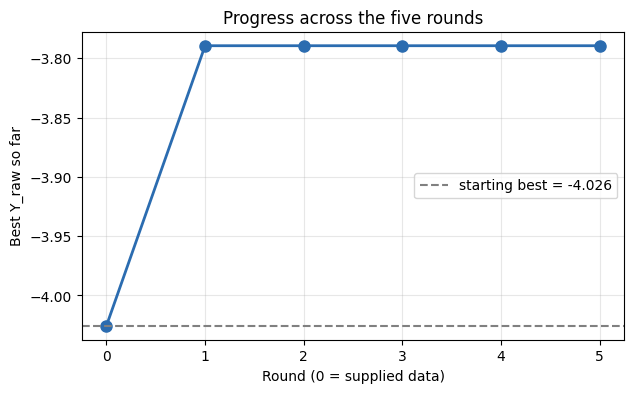

In [10]:
# Best value so far, after each round. A flat line means a whole round
# passed without improving on what was already known.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y_raw[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.3f}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best Y_raw so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
print("=" * 65)
print("Summary — Warehouse Placement 4D")
print("=" * 65)
print(f"  Total observations        : {len(X)}")
print(f"  Best Y_raw so far         : {Y_raw[best_raw_obs]:.6f}")
print(f"  at X                      : {X[best_raw_obs]}")
print(f"  Found in round            : {week[best_raw_obs]}")
print(f"  Y transform               : log(-Y_raw)")
print(f"  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel")
print(f"  Fitted length_scale       : {fitted_ls:.4g}  (single, shared)")
print(f"  Fitted noise_level        : {fitted_noise:.4g}")
print(f"  Model quality (R2)        : {r2:.3f}")
print(f"  EI xi parameter           : {xi}  (strong exploration)")
print(f"  Grid resolution           : {n_grid}^4 = {n_grid**4:,} points")
print(f"  Next point to sample      : {np.round(x_next, 6).tolist()}")
print(f"  Max EI value              : {ei_values[best_idx]:.6f}")
print("=" * 65)

Summary — Warehouse Placement 4D
  Total observations        : 35
  Best Y_raw so far         : -3.789395
  at X                      : [0.5777 0.4287 0.4325 0.2745]
  Found in round            : 1
  Y transform               : log(-Y_raw)
  Kernel                    : ConstantKernel x Matern(nu=2.5) + WhiteKernel
  Fitted length_scale       : 0.5797  (single, shared)
  Fitted noise_level        : 0.001
  Model quality (R2)        : 0.904
  EI xi parameter           : 0.1  (strong exploration)
  Grid resolution           : 20^4 = 160,000 points
  Next point to sample      : [1.0, 1.0, 0.842105, 0.0]
  Max EI value              : 0.035302


---

See `MODEL_CARD.md` for how this function compares with the other seven and for
the full list of assumptions and limitations, and `DATASHEET.md` for known gaps
and biases in the data.